# 02 — Classificador base

**Etapa 8 do roteiro.** O primeiro modelo quântico funcionando de ponta a ponta.

A cadeia completa:

$$x \;\mapsto\; \psi(x) \;\mapsto\; U(\theta)\,\psi(x) \;\mapsto\; \langle Z_0 \rangle \;\mapsto\; \hat{y}$$

Codificação: **angle encoding**, a mais direta. O roteiro é explícito de que aqui o
objetivo não é o melhor resultado possível, e sim código correto e controlado — este
classificador vira a linha de base contra a qual as outras codificações serão medidas.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp

from tccqml import model
from tccqml.data import load_dataset
from tccqml.embeddings import get_encoding
from tccqml.train import treinar

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = RAIZ / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

DATASET = "moons"
N_LAYERS = 2
EPOCAS = 30

## O circuito

Duas visões do mesmo circuito. A primeira mostra os blocos; a segunda, `level="device"`,
mostra as portas que a máquina realmente executa.

In [2]:
clf = model.build("angle", n_features=2, n_layers=N_LAYERS)
weights, bias = model.pesos_iniciais(clf)
x_exemplo = pnp.array([0.5, 2.0], requires_grad=False)

print("qubits:", clf.n_qubits, " parâmetros treináveis:", clf.n_params)
print()
print(qml.draw(clf.circuit, max_length=120, show_matrices=False)(x_exemplo, weights))
print()
print(qml.draw(clf.circuit, level="device", max_length=140)(x_exemplo, weights))

qubits: 2  parâmetros treináveis: 13

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

0: ──RY(0.50)──Rot(0.03,-0.10,0.08)──╭●─╭X──Rot(0.01,-0.03,-0.00)─╭●─╭X─┤  <Z>
1: ──RY(2.00)──Rot(0.09,-0.20,-0.13)─╰X─╰●──Rot(-0.09,0.09,0.08)──╰X─╰●─┤     


### Lendo o desenho

`RY(0.50)` e `RY(2.00)` **são os dados**. O ponto $x = (0.5,\ 2.0)$ não entrou como
número num registrador: cada coordenada virou o ângulo de uma rotação. É literalmente
o $x \mapsto \psi(x)$ — e é por isso que a normalização para $[0,\pi]$ do notebook
anterior importava.

Depois vêm os blocos `Rot` e os `CNOT`: esse é o $U(\theta)$, o ansatz treinável. Os
`CNOT` em anel criam entrelaçamento — sem eles os qubits evoluiriam de forma
independente e o modelo não conseguiria representar interação entre as features.

No fim, `<Z>` no qubit 0: uma única medição, um número em $[-1, 1]$.

## Um ponto virando estado

Aqui dá para ver o estado explicitamente — algo que só é possível em simulação.
Num computador quântico real você jamais leria essas amplitudes; obteria apenas
estatísticas de medição.

In [3]:
enc = get_encoding("angle")
dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def apenas_codificacao(x):
    enc.apply(x, wires=range(2))
    return qml.state()


psi = np.asarray(apenas_codificacao(x_exemplo))

print("x        =", np.asarray(x_exemplo))
print("psi(x)   =", np.round(psi.real, 4))
print("norma    =", round(float(np.sum(np.abs(psi) ** 2)), 8))
print()
for base, amp in zip(["|00>", "|01>", "|10>", "|11>"], psi):
    print(f"  {base}  amplitude {amp.real:+.4f}   probabilidade {abs(amp)**2:.4f}")

x        = [0.5 2. ]
psi(x)   = [0.5235 0.8153 0.1337 0.2082]
norma    = 1.0

  |00>  amplitude +0.5235   probabilidade 0.2741
  |01>  amplitude +0.8153   probabilidade 0.6647
  |10>  amplitude +0.1337   probabilidade 0.0179
  |11>  amplitude +0.2082   probabilidade 0.0433


Dois números clássicos viraram quatro amplitudes que somam 1 em módulo quadrado.
Note que o estado é **produto** — não há entrelaçamento aqui, porque o angle encoding
aplica uma rotação independente por qubit. O entrelaçamento só aparece no ansatz.

Essa é exatamente a limitação que motiva os *feature maps* entrelaçados da Etapa 4.5:
uma codificação que já introduz correlação entre features na hora de codificar.

## Treino

O gradiente do circuito vem do *parameter-shift* do PennyLane; a atualização dos
parâmetros é feita pelo Adam, um otimizador clássico. É essa combinação que faz o
modelo ser **híbrido quântico-clássico**.

In [4]:
ds = load_dataset(DATASET, n_samples=300, noise=0.15, seed=42)
resultado = treinar(clf, ds, epocas=EPOCAS, batch_size=20, lr=0.1, seed=42)

print()
print(f"acurácia treino: {resultado.acc_treino:.3f}")
print(f"acurácia teste : {resultado.acc_teste:.3f}")

época   1  custo=0.4409  treino=0.862  teste=0.844
época   5  custo=0.3723  treino=0.876  teste=0.844
época  10  custo=0.3732  treino=0.876  teste=0.833
época  15  custo=0.3725  treino=0.876  teste=0.856
época  20  custo=0.3718  treino=0.871  teste=0.844
época  25  custo=0.3715  treino=0.871  teste=0.844
época  30  custo=0.3728  treino=0.871  teste=0.844

acurácia treino: 0.871
acurácia teste : 0.844


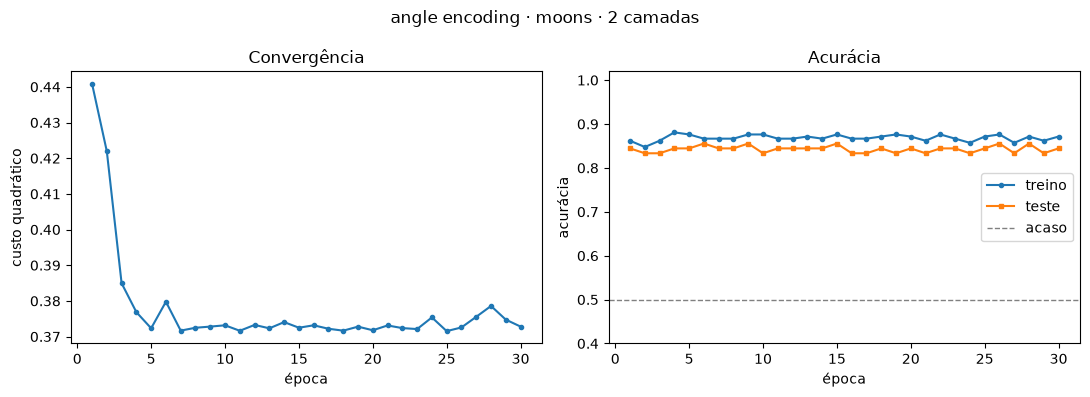

In [5]:
hist = resultado.historico

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(hist["epoca"], hist["custo"], marker="o", ms=3)
axes[0].set_xlabel("época"); axes[0].set_ylabel("custo quadrático")
axes[0].set_title("Convergência")

axes[1].plot(hist["epoca"], hist["acc_treino"], marker="o", ms=3, label="treino")
axes[1].plot(hist["epoca"], hist["acc_teste"], marker="s", ms=3, label="teste")
axes[1].axhline(0.5, ls="--", lw=1, color="gray", label="acaso")
axes[1].set_xlabel("época"); axes[1].set_ylabel("acurácia")
axes[1].set_ylim(0.4, 1.02); axes[1].legend()
axes[1].set_title("Acurácia")

fig.suptitle(f"angle encoding · {DATASET} · {N_LAYERS} camadas")
fig.tight_layout()
fig.savefig(FIGS / f"02_treino_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()

## Fronteira de decisão

O que o modelo aprendeu, desenhado sobre o plano inteiro. O fundo é a saída contínua
$\langle Z_0 \rangle + b$; a linha preta é onde ela cruza zero — a fronteira.

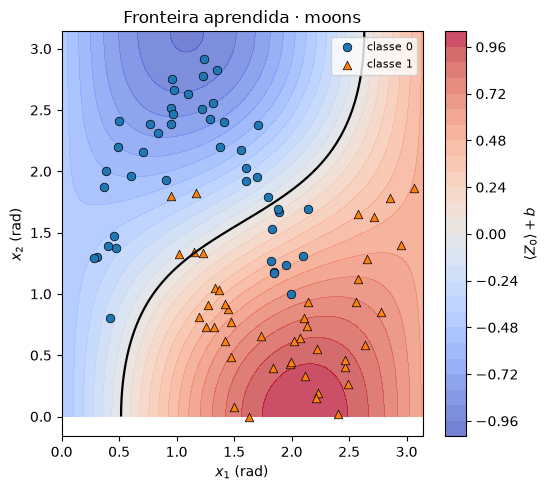

In [6]:
g = np.linspace(0, np.pi, 80)
XX, YY = np.meshgrid(g, g)
grade = np.c_[XX.ravel(), YY.ravel()]

Z = np.asarray(
    model.saida_continua(clf, resultado.weights, resultado.bias, grade), dtype=float
).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(5.6, 5))
mapa = ax.contourf(XX, YY, Z, levels=25, cmap="coolwarm", alpha=0.7, vmin=-1, vmax=1)
ax.contour(XX, YY, Z, levels=[0.0], colors="black", linewidths=1.6)

for classe, marcador in [(0, "o"), (1, "^")]:
    m = ds.y_test == classe
    ax.scatter(ds.X_test[m, 0], ds.X_test[m, 1], marker=marcador, s=38,
               edgecolor="k", linewidth=0.5, label=f"classe {classe}")

ax.set_xlabel(r"$x_1$ (rad)"); ax.set_ylabel(r"$x_2$ (rad)")
ax.set_title(f"Fronteira aprendida · {DATASET}")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(mapa, ax=ax, label=r"$\langle Z_0 \rangle + b$")
fig.tight_layout()
fig.savefig(FIGS / f"02_fronteira_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()

### O que observar

A fronteira do angle encoding com poucas camadas tende a ser **suave e pouco
encurvada**. Isso não é defeito de implementação: é consequência direta da Etapa 5.
A saída do circuito é

$$f_\theta(x) = \sum_{\omega \in \Omega} c_\omega(\theta)\, e^{i\omega x},$$

e uma codificação de camada única dá acesso a um conjunto $\Omega$ pequeno de
frequências. Poucas frequências, funções pouco oscilantes, fronteiras simples.

É essa a previsão que o *data re-uploading* deve derrubar: reinserindo $x$ várias vezes
ao longo do circuito, $\Omega$ cresce, e fronteiras fechadas como as do `circles`
passam a ser representáveis.

**Troque `DATASET` para `"xor"` e `"circles"` na primeira célula e rode de novo.**
Anote onde o angle encoding falha — esses são os casos que dão sentido à comparação
da Etapa 10.

## Registrando o resultado

A partir daqui todo experimento vira uma linha em CSV. A Etapa 10 pede tabelas
comparando codificações; construí-las lendo arquivos, e não re-treinando, é o que
mantém a análise barata e reprodutível.

In [7]:
RESULTADOS = RAIZ / "results"
RESULTADOS.mkdir(exist_ok=True)

hist.assign(**resultado.meta).to_csv(
    RESULTADOS / f"02_historico_{clf.encoding}_{ds.name}.csv", index=False
)

resumo = {**resultado.meta, "acc_treino": resultado.acc_treino, "acc_teste": resultado.acc_teste}
for k, v in resumo.items():
    print(f"{k:12s} {v}")

encoding     angle
dataset      moons
n_qubits     2
n_layers     2
n_params     13
epocas       30
lr           0.1
acc_treino   0.8714285714285714
acc_teste    0.8444444444444444


## Próximo passo

**Etapa 9.** Com esta base congelada — mesmo ansatz, mesmo dataset, mesmo protocolo —
acrescentar as demais codificações em `embeddings.py`: amplitude, data re-uploading e
o feature map entrelaçado. Cada uma vira uma entrada no dicionário `ENCODINGS`, e este
notebook roda igual trocando uma string.

Atenção a um detalhe que já se anuncia: o amplitude encoding com 2 features usa
**1 qubit**, não 2. O ansatz precisará se adaptar ao número de qubits que a codificação
determina — o `model.build` já está escrito para isso, mas vale conferir quando chegar lá.